In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


In [4]:
df=pd.read_csv(r"train_test_network.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  211043 non-null  object 
 1   src_port                211043 non-null  int64  
 2   dst_ip                  211043 non-null  object 
 3   dst_port                211043 non-null  int64  
 4   proto                   211043 non-null  object 
 5   service                 211043 non-null  object 
 6   duration                211043 non-null  float64
 7   src_bytes               211043 non-null  int64  
 8   dst_bytes               211043 non-null  int64  
 9   conn_state              211043 non-null  object 
 10  missed_bytes            211043 non-null  int64  
 11  src_pkts                211043 non-null  int64  
 12  src_ip_bytes            211043 non-null  int64  
 13  dst_pkts                211043 non-null  int64  
 14  dst_ip_bytes        

In [6]:
df['label'].value_counts()

,count
label,
1,161043
0,50000


In [7]:
df = df.drop(['src_ip', 'dst_ip', 'http_uri'], axis=1)

In [8]:
df

,src_port,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,4444,49178,tcp,-,290.371539,101568,2592,OTH,0,108,...,0,0,-,-,-,-,-,-,1,backdoor
1,49180,8080,tcp,-,0.000102,0,0,REJ,0,1,...,0,0,-,-,-,-,-,-,1,backdoor
2,49180,8080,tcp,-,0.000148,0,0,REJ,0,1,...,0,0,-,-,-,-,-,-,1,backdoor
3,49180,8080,tcp,-,0.000113,0,0,REJ,0,1,...,0,0,-,-,-,-,-,-,1,backdoor
4,49180,8080,tcp,-,0.000130,0,0,REJ,0,1,...,0,0,-,-,-,-,-,-,1,backdoor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211038,48286,80,tcp,http,65.376610,2665,322,S3,0,5,...,0,0,-,-,-,-,-,-,1,xss
211039,48288,80,tcp,http,65.710346,1987,322,S3,0,6,...,0,0,-,-,-,-,-,-,1,xss
211040,48292,80,tcp,http,65.766512,3922,322,S3,0,7,...,0,0,-,-,-,-,-,-,1,xss
211041,48294,80,tcp,http,65.753940,2401,322,S3,0,6,...,0,0,-,-,-,-,-,-,1,xss


In [9]:
import joblib
from sklearn.preprocessing import LabelEncoder
import os

categorical_cols = df.select_dtypes(include='object').columns
os.makedirs('label_encoders', exist_ok=True)  # create folder to save encoders

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # encode column
    joblib.dump(le, f'label_encoders/{col}_label_encoder.pkl')  # save this column's encoder


In [10]:
df.columns

Index(['src_port', 'dst_port', 'proto', 'service', 'duration', 'src_bytes',
       'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes',
       'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype',
       'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected',
       'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established',
       'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method',
       'http_version', 'http_request_body_len', 'http_response_body_len',
       'http_status_code', 'http_user_agent', 'http_orig_mime_types',
       'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice',
       'label', 'type'],
      dtype='object')

In [11]:
df.dtypes

,0
src_port,int64
dst_port,int64
proto,int64
service,int64
duration,float64
src_bytes,int64
dst_bytes,int64
conn_state,int64
missed_bytes,int64
src_pkts,int64


In [12]:
X = df.drop(['label','type'], axis=1)
y = df['label']


In [13]:
X.shape

(211043, 39)

In [14]:
y.shape

(211043,)

In [15]:
X.columns

Index(['src_port', 'dst_port', 'proto', 'service', 'duration', 'src_bytes',
       'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes',
       'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype',
       'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected',
       'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established',
       'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method',
       'http_version', 'http_request_body_len', 'http_response_body_len',
       'http_status_code', 'http_user_agent', 'http_orig_mime_types',
       'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice'],
      dtype='object')

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
class DualWeightDense(tf.keras.layers.Layer):
    def __init__(self, units, dual_factor=0.5, **kwargs):
        super(DualWeightDense, self).__init__(**kwargs)
        self.units = units
        self.dual_factor = dual_factor

    def build(self, input_shape):
        self.w1 = self.add_weight(shape=(input_shape[-1], self.units),
                                  initializer='random_normal',
                                  trainable=True)
        self.w2 = self.add_weight(shape=(input_shape[-1], self.units),
                                  initializer='random_normal',
                                  trainable=True)
        self.b = self.add_weight(shape=(self.units,),
                                 initializer='zeros',
                                 trainable=True)

    def call(self, inputs):
        output = tf.matmul(inputs, self.dual_factor * self.w1 + (1 - self.dual_factor) * self.w2) + self.b
        return tf.nn.relu(output)


In [19]:
# Build Model
model = Sequential()
model.add(tf.keras.Input(shape=(X_train.shape[1],)))
model.add(DualWeightDense(256, dual_factor=0.7))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary classification

In [20]:
# Compile model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [21]:
# Train model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_split=0.2,
                    epochs=50, batch_size=128, callbacks=[early_stop])

Epoch 1/50
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9570 - loss: 0.1125 - val_accuracy: 0.9768 - val_loss: 0.0527
Epoch 2/50
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9781 - loss: 0.0511 - val_accuracy: 0.9794 - val_loss: 0.0488
Epoch 3/50
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9790 - loss: 0.0487 - val_accuracy: 0.9779 - val_loss: 0.0412
Epoch 4/50
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9818 - loss: 0.0448 - val_accuracy: 0.9788 - val_loss: 0.0445
Epoch 5/50
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9832 - loss: 0.0416 - val_accuracy: 0.9936 - val_loss: 0.0410
Epoch 6/50
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9866 - loss: 0.0382 - val_accuracy: 0.9939 - val_loss: 0.0260
Epoch 7/50
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9885 - loss: 0.0350 - val_accuracy: 0.9942 - val_loss: 0.0253
Epoch 8/50
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9901 - loss: 0.0302 

In [22]:
# Evaluate
y_pred = (model.predict(X_test) > 0.5).astype("int32")

1320/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [23]:

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     10000
           1       1.00      1.00      1.00     32209

    accuracy                           0.99     42209
   macro avg       0.99      0.99      0.99     42209
weighted avg       0.99      0.99      0.99     42209

Accuracy Score: 0.9947641498258665


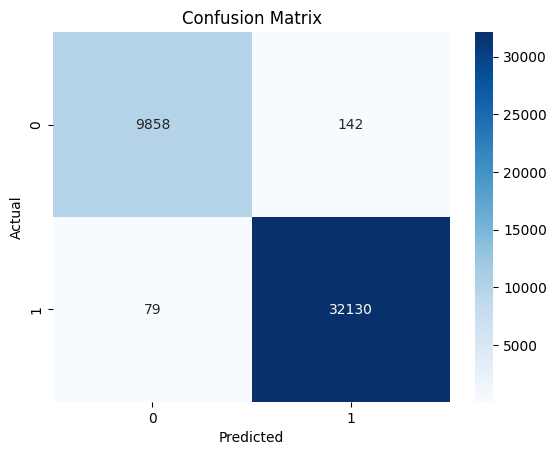

In [24]:
# Confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

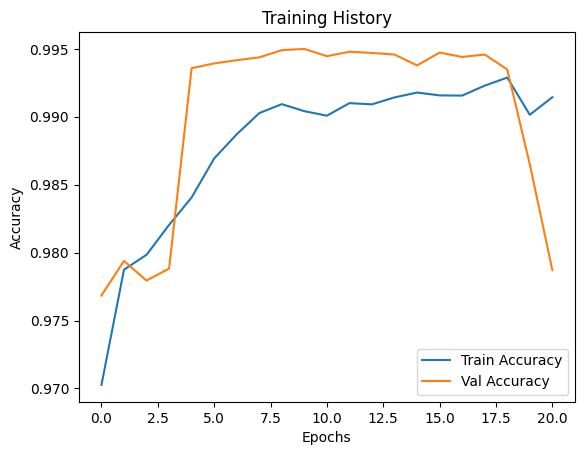

In [25]:
# Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training History")
plt.show()

In [26]:
# Save the model
model.save('dwu_obn_network_model.h5')


In [59]:
from tensorflow.keras.models import load_model

# Register custom layer if using DualWeightDense
class DualWeightDense(tf.keras.layers.Layer):
    def __init__(self, units, dual_factor=0.5, **kwargs):
        super(DualWeightDense, self).__init__(**kwargs)
        self.units = units
        self.dual_factor = dual_factor

    def build(self, input_shape):
        self.w1 = self.add_weight(shape=(input_shape[-1], self.units),
                                  initializer='random_normal',
                                  trainable=True)
        self.w2 = self.add_weight(shape=(input_shape[-1], self.units),
                                  initializer='random_normal',
                                  trainable=True)
        self.b = self.add_weight(shape=(self.units,),
                                 initializer='zeros',
                                 trainable=True)

    def call(self, inputs):
        output = tf.matmul(inputs, self.dual_factor * self.w1 + (1 - self.dual_factor) * self.w2) + self.b
        return tf.nn.relu(output)

# Load the model
model = load_model('dwu_obn_network_model.h5', custom_objects={'DualWeightDense': DualWeightDense})


In [60]:
import numpy as np
import pandas as pd

def predict_realtime(input_list, feature_names, scaler, model, le):
    """
    input_list: list of feature values in the same order as feature_names
    feature_names: list of column names used during training
    scaler: fitted StandardScaler
    model: trained model
    le: fitted LabelEncoder (for categorical columns)
    """
    # Convert list to DataFrame
    input_df = pd.DataFrame([input_list], columns=feature_names)

    # Encode categorical features (if any)
    for col in input_df.select_dtypes(include='object').columns:
        input_df[col] = le.transform(input_df[col])

    # Scale features
    input_scaled = scaler.transform(input_df)

    # Predict
    prediction = model.predict(input_scaled)
    label = (prediction > 0.5).astype("int32")[0][0]

    return "Anomaly Detected" if label == 1 else "Normal"


In [61]:
import joblib
joblib.dump(scaler, 'network_scaler.pkl')


['network_scaler.pkl']

In [30]:
X_test.shape

(42209, 39)

In [31]:
df.shape

(211043, 41)

In [32]:
df

,src_port,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,4444,49178,1,0,290.371539,101568,2592,0,0,108,...,0,0,0,0,0,0,0,0,1,0
1,49180,8080,1,0,0.000102,0,0,1,0,1,...,0,0,0,0,0,0,0,0,1,0
2,49180,8080,1,0,0.000148,0,0,1,0,1,...,0,0,0,0,0,0,0,0,1,0
3,49180,8080,1,0,0.000113,0,0,1,0,1,...,0,0,0,0,0,0,0,0,1,0
4,49180,8080,1,0,0.000130,0,0,1,0,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211038,48286,80,1,5,65.376610,2665,322,9,0,5,...,0,0,0,0,0,0,0,0,1,9
211039,48288,80,1,5,65.710346,1987,322,9,0,6,...,0,0,0,0,0,0,0,0,1,9
211040,48292,80,1,5,65.766512,3922,322,9,0,7,...,0,0,0,0,0,0,0,0,1,9
211041,48294,80,1,5,65.753940,2401,322,9,0,6,...,0,0,0,0,0,0,0,0,1,9


In [34]:
df1=pd.read_csv(r"train_test_network.csv")

In [35]:
df1 = df1.drop(['src_ip', 'dst_ip', 'http_uri'], axis=1)

In [52]:
row_values = df1.loc[1].apply(lambda x: x.item() if hasattr(x, "item") else x).to_list()

formatted = "[" + ", ".join(f'"{x}"' if isinstance(x, str) else str(x) for x in row_values) + "]"
print(formatted)

[49180, 8080, "tcp", "-", 0.000102, 0, 0, "REJ", 0, 1, 52, 1, 40, "-", 0, 0, 0, "-", "-", "-", "-", "-", "-", "-", "-", "-", "-", "-", "-", "-", 0, 0, 0, "-", "-", "-", "-", "-", "-", 1, "backdoor"]


In [54]:
feature_names=['src_port', 'dst_port', 'proto', 'service', 'duration', 'src_bytes',
       'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes',
       'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype',
       'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected',
       'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established',
       'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method',
       'http_version', 'http_request_body_len', 'http_response_body_len',
       'http_status_code', 'http_user_agent', 'http_orig_mime_types',
       'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice']

In [55]:
import joblib
scaler=joblib.load('/content/network_scaler.pkl')

In [ ]:
result = predict_realtime(formatted, feature_names, scaler, model, le)
print(result)

In [37]:
df1.shape

(211043, 41)

In [38]:
df1.columns

Index(['src_port', 'dst_port', 'proto', 'service', 'duration', 'src_bytes',
       'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes',
       'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype',
       'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected',
       'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established',
       'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method',
       'http_version', 'http_request_body_len', 'http_response_body_len',
       'http_status_code', 'http_user_agent', 'http_orig_mime_types',
       'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice',
       'label', 'type'],
      dtype='object')

In [39]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 41 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_port                211043 non-null  int64  
 1   dst_port                211043 non-null  int64  
 2   proto                   211043 non-null  object 
 3   service                 211043 non-null  object 
 4   duration                211043 non-null  float64
 5   src_bytes               211043 non-null  int64  
 6   dst_bytes               211043 non-null  int64  
 7   conn_state              211043 non-null  object 
 8   missed_bytes            211043 non-null  int64  
 9   src_pkts                211043 non-null  int64  
 10  src_ip_bytes            211043 non-null  int64  
 11  dst_pkts                211043 non-null  int64  
 12  dst_ip_bytes            211043 non-null  int64  
 13  dns_query               211043 non-null  object 
 14  dns_qclass          

In [40]:
X.columns

Index(['src_port', 'dst_port', 'proto', 'service', 'duration', 'src_bytes',
       'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes',
       'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype',
       'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected',
       'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established',
       'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method',
       'http_version', 'http_request_body_len', 'http_response_body_len',
       'http_status_code', 'http_user_agent', 'http_orig_mime_types',
       'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice'],
      dtype='object')

In [41]:
X_train

array([[ 0.59871267, -0.33509494, -0.49236853, ..., -0.03287006,
        -0.02720021, -0.04110609],
       [ 0.7647645 , -0.33509494, -0.49236853, ..., -0.03287006,
        -0.02720021, -0.04110609],
       [-1.99751745, -0.18448071, -0.49236853, ..., -0.03287006,
        -0.02720021, -0.04110609],
       ...,
       [ 0.47575352, -0.33509494, -0.49236853, ..., -0.03287006,
        -0.02720021, -0.04110609],
       [ 0.78853798, -0.33774418,  1.99747025, ..., -0.03287006,
        -0.02720021, -0.04110609],
       [ 1.15031964, -0.33509494, -0.49236853, ..., -0.03287006,
        -0.02720021, -0.04110609]])

In [63]:
!zip -r label_encoders.zip label_encoders/


  adding: label_encoders/ (stored 0%)
  adding: label_encoders/weird_notice_label_encoder.pkl (deflated 35%)
  adding: label_encoders/http_version_label_encoder.pkl (deflated 35%)
  adding: label_encoders/proto_label_encoder.pkl (deflated 35%)
  adding: label_encoders/ssl_subject_label_encoder.pkl (deflated 40%)
  adding: label_encoders/ssl_resumed_label_encoder.pkl (deflated 34%)
  adding: label_encoders/type_label_encoder.pkl (deflated 34%)
  adding: label_encoders/http_resp_mime_types_label_encoder.pkl (deflated 37%)
  adding: label_encoders/weird_name_label_encoder.pkl (deflated 36%)
  adding: label_encoders/dns_AA_label_encoder.pkl (deflated 34%)
  adding: label_encoders/http_orig_mime_types_label_encoder.pkl (deflated 35%)
  adding: label_encoders/weird_addl_label_encoder.pkl (deflated 35%)
  adding: label_encoders/conn_state_label_encoder.pkl (deflated 35%)
  adding: label_encoders/service_label_encoder.pkl (deflated 34%)
  adding: label_encoders/http_user_agent_label_encoder.pk